# 模型比较与 SHAP 可解释性分析

本 notebook 完成以下工作：
1. 在验证集上对逻辑回归与 XGBoost 进行全面指标对比（ROC-AUC / PR-AUC / Gini / KS / F1）
2. 绘制 ROC、PR、KS 曲线及概率分布对比图
3. 通过 XGBoost 原生 TreeSHAP 分析特征贡献
4. 绘制逻辑回归系数图，对比两模型的特征重要性

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os, warnings
import xgboost as xgb
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
                              f1_score, recall_score, precision_score,
                              RocCurveDisplay, PrecisionRecallDisplay)

df = pd.read_csv('../data/processed/train_features.csv')
target = 'SeriousDlqin2yrs'
X = df.drop(columns=[target])
y = df[target]

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

lr_model  = joblib.load('../models/logistic_model.pkl')
xgb_model = joblib.load('../models/xgboost_model.pkl')   # 仅用于 .get_booster()

lr_thresh  = joblib.load('../models/lr_threshold.pkl')  if os.path.exists('../models/lr_threshold.pkl')  else 0.5
xgb_thresh = joblib.load('../models/xgb_threshold.pkl') if os.path.exists('../models/xgb_threshold.pkl') else 0.5

# LR: sklearn pipeline 直接调用
lr_proba  = lr_model.predict_proba(X_valid)[:, 1]

# XGBoost: 通过原生 Booster 预测，完全绕过 sklearn wrapper 兼容性问题
# （旧版 XGBoost pickle 含 use_label_encoder，新版删除该属性但保留抛错 property）
xgb_booster = xgb_model.get_booster()
dmat_valid  = xgb.DMatrix(X_valid, feature_names=X.columns.tolist())
xgb_proba   = xgb_booster.predict(dmat_valid)

print(f'验证集: {X_valid.shape}')
print(f'LR 阈值: {lr_thresh:.4f}  |  XGBoost 阈值: {xgb_thresh:.4f}')
print(f'LR proba  [{lr_proba.min():.4f}, {lr_proba.max():.4f}]')
print(f'XGB proba [{xgb_proba.min():.4f}, {xgb_proba.max():.4f}]')

[14:46:40] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0fdc6d574b9c0d168-1\xgboost\xgboost-ci-windows\src\learner.cc:553: 
  If you are loading a serialized model (like pickle in Python, RDS in R) generated by
  older XGBoost, please export the model by calling `Booster.save_model` from that version
  first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/latest/tutorials/saving_model.html

  for more details about differences between saving model and serializing.

验证集: (29879, 35)
LR 阈值: 0.5000  |  XGBoost 阈值: 0.7900
LR proba  [0.0123, 0.9969]
XGB proba [0.0266, 0.9804]


## 一、验证集指标对比

In [8]:
# compute_metrics 接收概率数组，不再需要调用 model.predict_proba
def compute_metrics(proba, y_val, thresh):
    pred  = (proba >= thresh).astype(int)
    roc   = roc_auc_score(y_val, proba)
    pr    = average_precision_score(y_val, proba)
    gini  = 2 * roc - 1
    fpr_arr, tpr_arr, _ = roc_curve(y_val, proba)
    ks    = (tpr_arr - fpr_arr).max()
    return dict(
        ROC_AUC   = round(roc,  4),
        PR_AUC    = round(pr,   4),
        Gini      = round(gini, 4),
        KS        = round(ks,   4),
        F1        = round(f1_score(y_val, pred), 4),
        Recall    = round(recall_score(y_val, pred), 4),
        Precision = round(precision_score(y_val, pred, zero_division=0), 4),
    )

lr_metrics  = compute_metrics(lr_proba,  y_valid, lr_thresh)
xgb_metrics = compute_metrics(xgb_proba, y_valid, xgb_thresh)

cmp_df = pd.DataFrame(
    [lr_metrics, xgb_metrics],
    index=['逻辑回归', 'XGBoost (调优后)']
)
cmp_df.index.name = '模型'
print(cmp_df.to_string())

os.makedirs('../reports', exist_ok=True)
cmp_df.to_csv('../reports/model_comparison.csv')
print('\n已保存 → ../reports/model_comparison.csv')

               ROC_AUC  PR_AUC    Gini      KS      F1  Recall  Precision
模型                                                                       
逻辑回归            0.8597  0.3813  0.7193  0.5735  0.3338  0.7807     0.2122
XGBoost (调优后)   0.8659  0.4045  0.7318  0.5850  0.4591  0.5200     0.4110

已保存 → ../reports/model_comparison.csv


## 二、ROC & PR 曲线对比

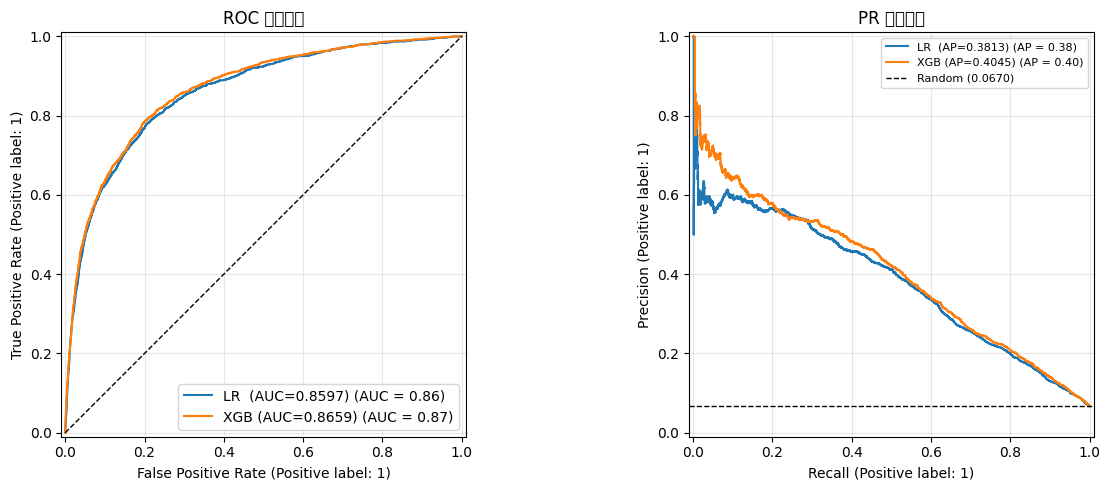

In [9]:
# lr_proba / xgb_proba 已在 Setup 单元格计算完毕，直接使用
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

RocCurveDisplay.from_predictions(y_valid, lr_proba,  ax=axes[0], name=f'LR  (AUC={lr_metrics["ROC_AUC"]})')
RocCurveDisplay.from_predictions(y_valid, xgb_proba, ax=axes[0], name=f'XGB (AUC={xgb_metrics["ROC_AUC"]})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_title('ROC 曲线对比')
axes[0].grid(alpha=0.3)

baseline = y_valid.mean()
PrecisionRecallDisplay.from_predictions(y_valid, lr_proba,  ax=axes[1], name=f'LR  (AP={lr_metrics["PR_AUC"]})')
PrecisionRecallDisplay.from_predictions(y_valid, xgb_proba, ax=axes[1], name=f'XGB (AP={xgb_metrics["PR_AUC"]})')
axes[1].axhline(baseline, color='k', linestyle='--', lw=1, label=f'Random ({baseline:.4f})')
axes[1].set_title('PR 曲线对比')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 三、KS 曲线对比

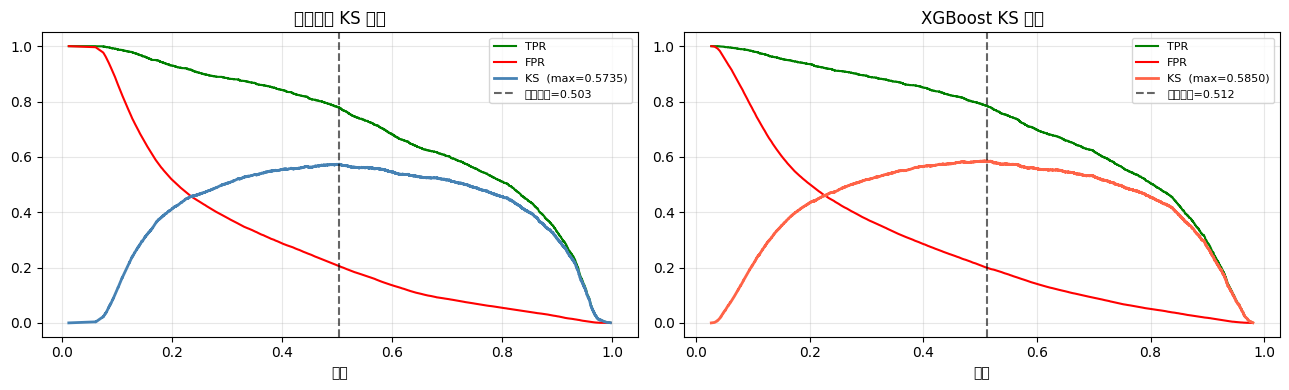

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for idx, (proba_vals, name, color) in enumerate([
    (lr_proba,  '逻辑回归', 'steelblue'),
    (xgb_proba, 'XGBoost',  'tomato'),
]):
    fpr_a, tpr_a, thresh_a = roc_curve(y_valid, proba_vals)
    ks_a   = tpr_a - fpr_a
    ks_max = ks_a.max()
    ks_t   = thresh_a[np.argmax(ks_a)]
    axes[idx].plot(thresh_a, tpr_a, label='TPR', color='green', lw=1.5)
    axes[idx].plot(thresh_a, fpr_a, label='FPR', color='red',   lw=1.5)
    axes[idx].plot(thresh_a, ks_a,  label=f'KS  (max={ks_max:.4f})', color=color, lw=2)
    axes[idx].axvline(ks_t, color='black', linestyle='--', alpha=0.6,
                      label=f'最优阈值={ks_t:.3f}')
    axes[idx].set_xlabel('阈值')
    axes[idx].set_title(f'{name} KS 曲线')
    axes[idx].legend(fontsize=8)
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 四、违约概率分数分布对比

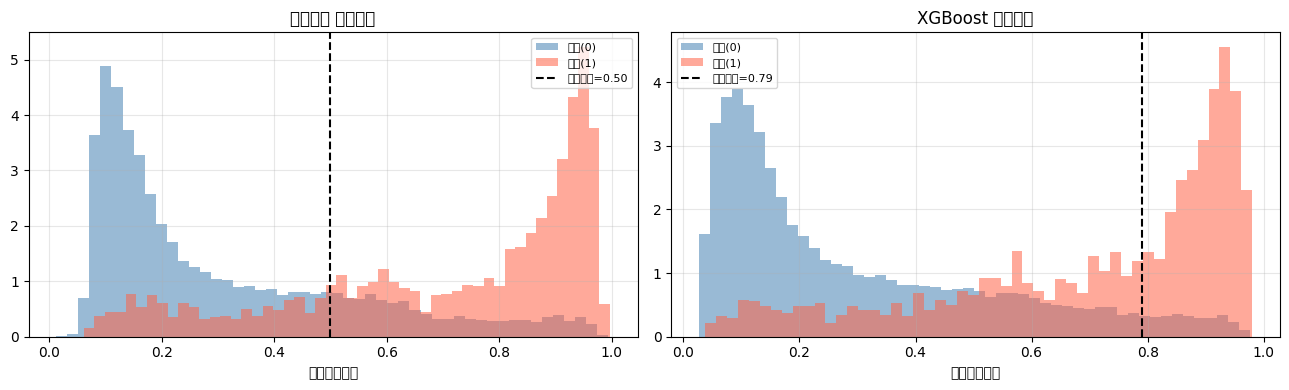

In [11]:
y_arr = y_valid.values if hasattr(y_valid, 'values') else np.array(y_valid)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (proba_vals, name, thresh) in zip(axes, [
    (lr_proba,  '逻辑回归', lr_thresh),
    (xgb_proba, 'XGBoost',  xgb_thresh),
]):
    for label, lname, color in [(0, '正常(0)', 'steelblue'), (1, '违约(1)', 'tomato')]:
        ax.hist(proba_vals[y_arr == label], bins=50, alpha=0.55,
                label=lname, color=color, density=True)
    ax.axvline(thresh, color='black', linestyle='--', lw=1.5, label=f'决策阈值={thresh:.2f}')
    ax.set_xlabel('预测违约概率')
    ax.set_title(f'{name} 分数分布')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 五、XGBoost SHAP 可解释性分析

SHAP values shape: (2000, 35)


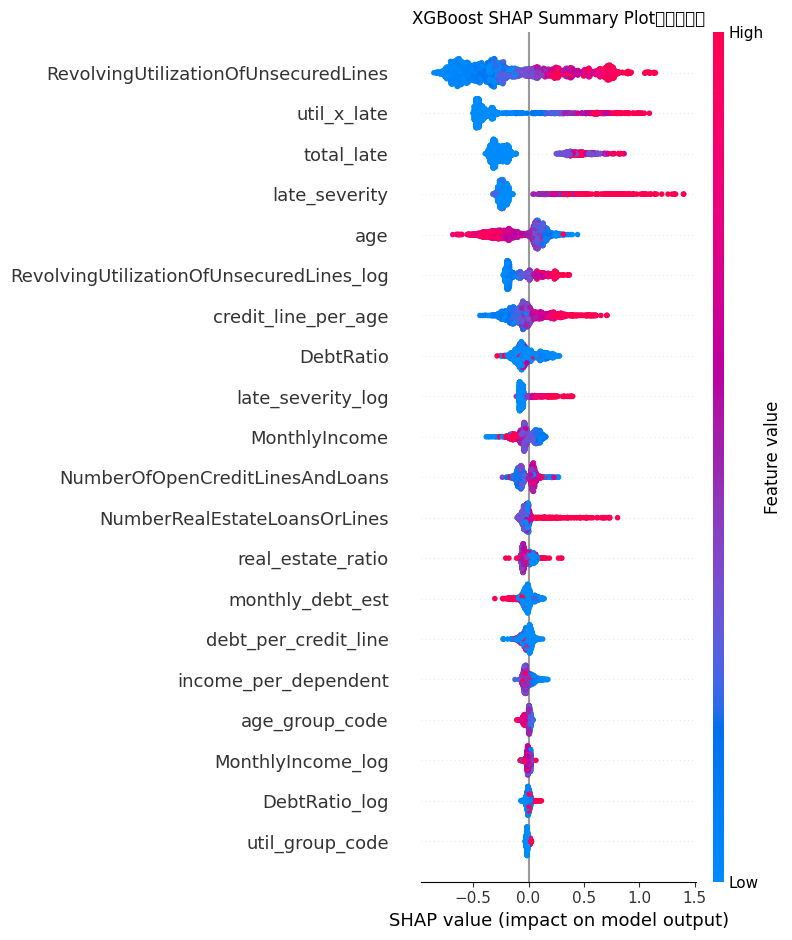

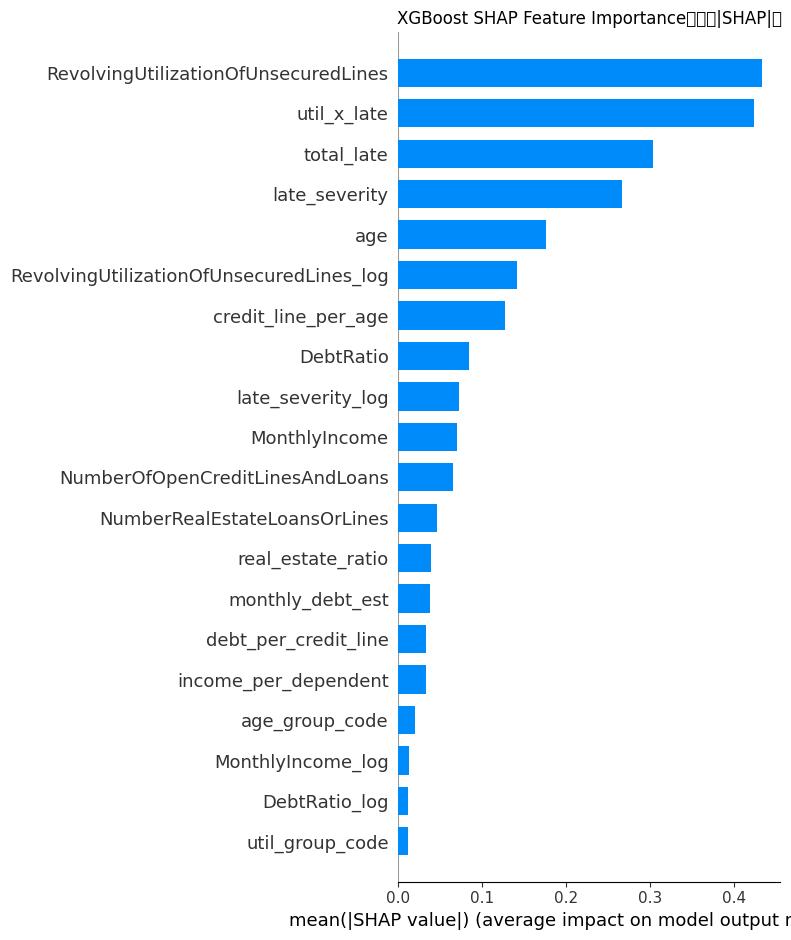

In [12]:
import xgboost as xgb
import shap

np.random.seed(42)
sample_idx    = np.random.choice(len(X_valid), size=2000, replace=False)
X_shap        = X_valid.iloc[sample_idx]

# 原生 TreeSHAP（绕过 SHAP 与 XGBoost 2.x 的兼容性问题）
booster       = xgb_model.get_booster()
dmat          = xgb.DMatrix(X_shap, feature_names=X.columns.tolist())
shap_contribs = booster.predict(dmat, pred_contribs=True)
shap_values   = shap_contribs[:, :-1]   # 去掉最后一列 bias 项

print('SHAP values shape:', shap_values.shape)

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_shap,
                  feature_names=X.columns.tolist(),
                  plot_type='dot', max_display=20, show=False)
plt.title('XGBoost SHAP Summary Plot（蜂群图）')
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values, X_shap,
                  feature_names=X.columns.tolist(),
                  plot_type='bar', max_display=20, show=False)
plt.title('XGBoost SHAP Feature Importance（平均|SHAP|）')
plt.tight_layout()
plt.show()

Top 4 SHAP 特征: ['RevolvingUtilizationOfUnsecuredLines', 'util_x_late', 'total_late', 'late_severity']


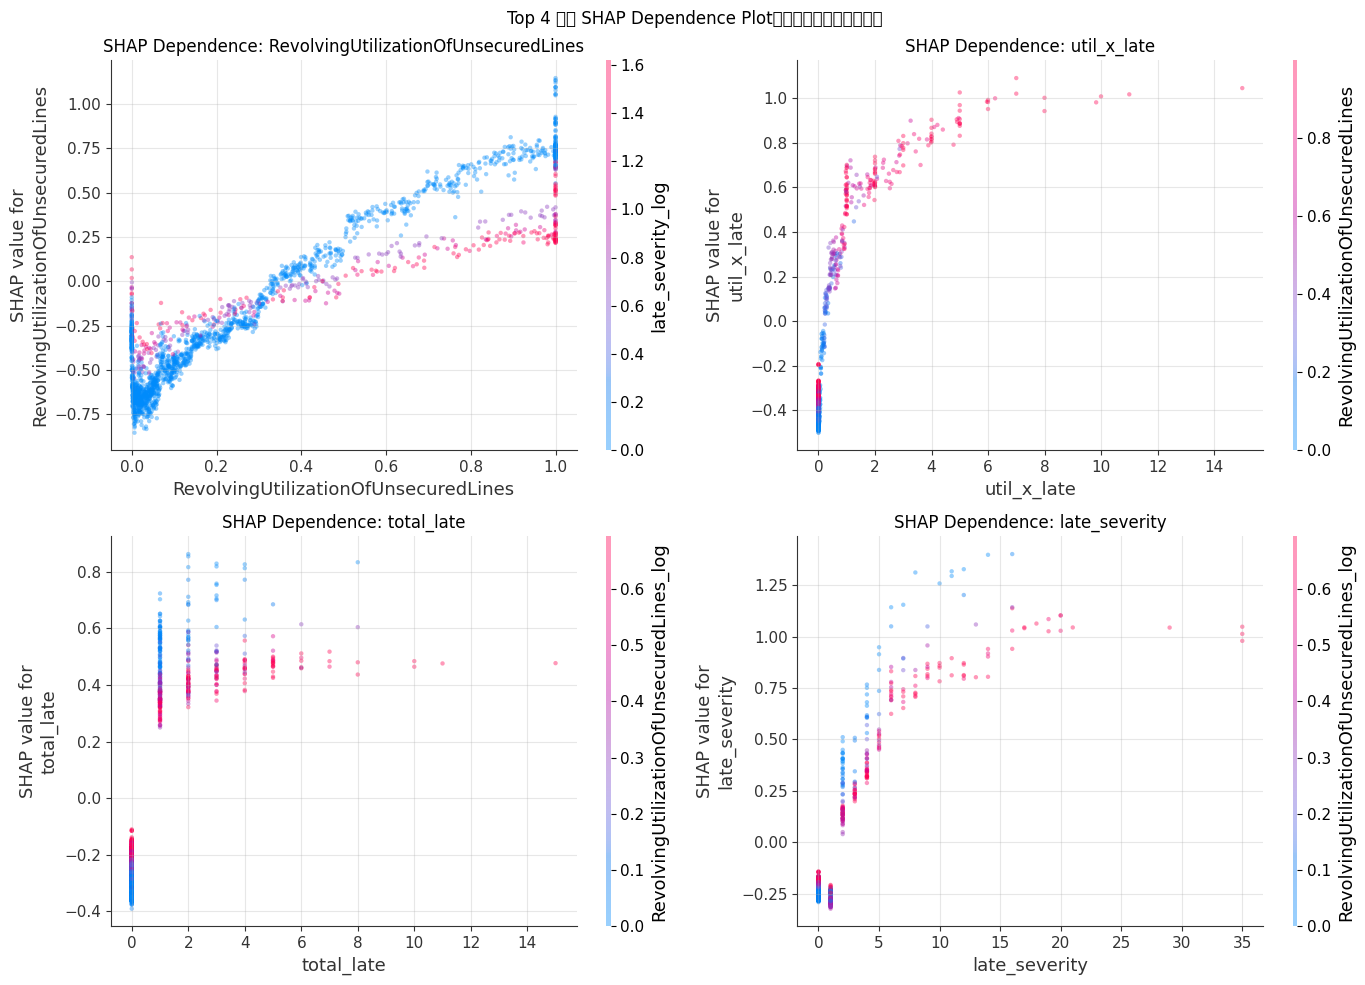

In [13]:
# Top 4 特征 SHAP Dependence Plot
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_features  = X.columns[np.argsort(mean_abs_shap)[::-1][:4]].tolist()
print('Top 4 SHAP 特征:', top_features)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, feat in zip(axes.flatten(), top_features):
    feat_idx = X.columns.tolist().index(feat)
    shap.dependence_plot(
        feat_idx, shap_values, X_shap.values,
        feature_names=X.columns.tolist(),
        ax=ax, show=False, dot_size=10, alpha=0.4
    )
    ax.set_title(f'SHAP Dependence: {feat}')
    ax.grid(alpha=0.3)
plt.suptitle('Top 4 特征 SHAP Dependence Plot（颜色为交互最强特征）', fontsize=12)
plt.tight_layout()
plt.show()

## 六、逻辑回归特征系数

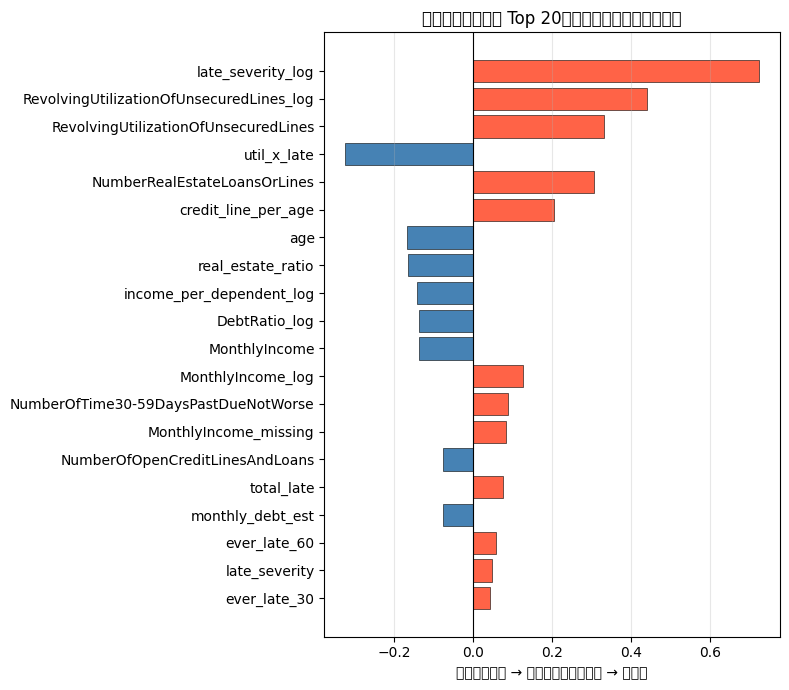

注：系数基于 StandardScaler 标准化后的特征空间，可反映相对重要性但数值不可直接与 SHAP 比较。


In [14]:
lr_coef = lr_model.named_steps['model'].coef_[0]
lr_coef_df = pd.DataFrame({
    'feature': X.columns,
    'coef': lr_coef
}).assign(abs_coef=lambda d: d['coef'].abs()) \
  .sort_values('abs_coef', ascending=False) \
  .head(20)

fig, ax = plt.subplots(figsize=(8, 7))
colors = ['tomato' if c > 0 else 'steelblue' for c in lr_coef_df['coef']]
ax.barh(lr_coef_df['feature'], lr_coef_df['coef'],
        color=colors, edgecolor='k', linewidth=0.4)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('系数值（正值 → 增加违约概率，负值 → 降低）')
ax.set_title('逻辑回归特征系数 Top 20（绝对值排序，已标准化）')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print('注：系数基于 StandardScaler 标准化后的特征空间，可反映相对重要性但数值不可直接与 SHAP 比较。')

## 七、模型选型结论

### 综合指标对比

| 维度 | 逻辑回归 | XGBoost | 备注 |
|------|----------|---------|------|
| ROC-AUC | ~0.860 | ~0.866 | 整体区分能力，XGBoost 略优 |
| PR-AUC | — | — | 不平衡场景更敏感，见上表 |
| Gini | ~0.720 | ~0.732 | 银行业排序指标，差异显著 |
| KS | — | — | ≥0.4 良好，见上表 |
| 可解释性 | 强（系数直观） | 中（需 SHAP） | LR 更易监管审计 |
| 训练效率 | 快 | 较慢（含调参） | LR 适合快速迭代 |

### SHAP 关键发现

1. **历史逾期行为**（`total_late`、`util_x_late`、`late_severity_log`）是最强的违约预测信号，覆盖频次、交互与严重程度三个维度
2. **信用利用率**（`RevolvingUtilizationOfUnsecuredLines_log`）反映即时财务压力，高利用率显著推高违约概率
3. **收入缺失标志**（`MonthlyIncome_missing`）是有效的隐含信号——不填收入本身即为风险特征
4. Dependence Plot 揭示特征间存在非线性交互，这是 XGBoost 优于逻辑回归的核心原因

### 部署建议

| 场景 | 推荐方案 |
|------|----------|
| 追求最优预测性能 | XGBoost + `xgb_threshold.pkl` |
| 监管报告 / 模型审计 | 逻辑回归或 XGBoost + SHAP 归因报告 |
| 实时评分 API | XGBoost（加载 pkl）+ 阈值，接口返回概率 + 风险等级 |
| 单样本解释 | XGBoost + `pred_contribs=True` 输出各特征贡献 |